In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/__results__.html
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/class_weights_32x32.json
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/malviznet_32x32_split.npz
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/__notebook__.ipynb
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/malimg.npz
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/__output__.json
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/custom.css


# MalVizNet — Phase 2: Resolution Ablation (32×32 Native)

**Scope:** Re-running all 12 CNN architectures (M-1–M-12) at native 32×32 resolution, 
no upscaling — extending Phase 1 (128×128) to test resolution sensitivity.

**Methodology:** Same empirical-correction approach as Phase 1 — start from literal 
paper spec (Pinhero et al., 2021, Table 2), patch only where a model demonstrably 
fails to train (e.g., spatial dimensions collapsing to 0 before dense/GAP layers).

**Consistency with Phase 1:**
- Same dataset (`malimg.npz`, Hydrogenion/Malimg mirror, 9,339 samples, 25 classes)
- Same stratified 70/30 split, `random_state=42`
- Same class-weight computation (inverse-frequency, `compute_class_weight('balanced')`)
- Same augmentation pipeline (brightness/contrast/noise/pad-crop), scaled to 32×32 
  (margins: 36×36 pad → 32×32 crop, vs. Phase 1's 140×140 → 128×128)
- **No resize/interpolation step** — this is genuinely native resolution, unlike 
  Phase 1's INTER_CUBIC upscale from the same source

**Checkpoint dataset:** `malviznet-32x32-checkpoints`


In [2]:
import urllib.request
import numpy as np

url = "https://raw.githubusercontent.com/Hydrogenion/Malimg/master/malimg.npz"
urllib.request.urlretrieve(url, "malimg.npz")

data = np.load("malimg.npz", allow_pickle=True)
arr = data['arr']  # (9339, 2) object array: [image, label] per row
print(arr.shape, arr[0][0].shape, arr[0][0].dtype)
print("Label range:", min(r[1] for r in arr), "-", max(r[1] for r in arr))

(9339, 2) (32, 32) uint8
Label range: 0 - 24


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Separate images and labels
images = np.stack([r[0] for r in arr])   # (9339, 32, 32) uint8
labels = np.array([r[1] for r in arr], dtype=np.int64)

# Normalize to [0,1] float32 — no resize, native 32x32
images = images.astype(np.float32) / 255.0
images = images[..., np.newaxis]  # (9339, 32, 32, 1) — add channel dim

# Stratified 70/30 split, same seed as Phase 1
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

# Class weights — inverse-frequency, same as Phase 1
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print("Train class distribution (min/max):", 
      np.bincount(y_train).min(), "/", np.bincount(y_train).max())

Train: (6537, 32, 32, 1) Test: (2802, 32, 32, 1)
Train class distribution (min/max): 56 / 2064


In [9]:
np.savez_compressed(
    '/kaggle/working/malviznet_32x32_split.npz',
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test
)
import json
with open('/kaggle/working/class_weights_32x32.json', 'w') as f:
    json.dump({str(k): v for k, v in class_weight_dict.items()}, f)

print("Saved split + class weights to /kaggle/working/")

Saved split + class weights to /kaggle/working/


In [5]:
import tensorflow as tf

def augment(image, label):
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
    image = image + noise
    image = tf.image.resize_with_crop_or_pad(image, 35, 35)
    image = tf.image.random_crop(image, size=[32, 32, 1])
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def make_dataset(X, y, training=True, batch_size=64):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=42)
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True, batch_size=64)
test_ds = make_dataset(X_test, y_test, training=False, batch_size=64)

print(train_ds, test_ds)

I0000 00:00:1789713380.885237      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789713380.888201      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))> <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


In [6]:
from tensorflow.keras import layers, models, applications

NUM_CLASSES = 25
INPUT_SHAPE = (32, 32, 1)

In [10]:
def build_m1():
    m = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, strides=2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M1')
    return m

model = build_m1()
model.summary()

Model: "M1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061,497 (4.05 MB)

 Trainable params: 1,061,497 (4.05 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
def build_m2():
    m = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, strides=2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M2')
    return m

model = build_m2()
model.summary()

Model: "M2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,052,249 (4.01 MB)

 Trainable params: 1,052,249 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
def build_m3():
    m = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, strides=2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M3')
    return m

model = build_m3()
model.summary()

Model: "M3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,070,745 (4.08 MB)

 Trainable params: 1,070,745 (4.08 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
def build_m4():
    m = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, strides=2),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M4')
    return m

model = build_m4()
model.summary()

Model: "M4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061,497 (4.05 MB)

 Trainable params: 1,061,497 (4.05 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
def build_m5():
    m = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.GlobalMaxPooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M5')
    return m

model = build_m5()
model.summary()


Model: "M5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,769 (30.35 KB)

 Trainable params: 7,769 (30.35 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
def build_m6():
    m = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.GlobalMaxPooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M6')
    return m

model = build_m6()
model.summary()

Model: "M6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_1          │ (None, 32)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,017 (66.47 KB)

 Trainable params: 17,017 (66.47 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
def build_m7():
    m = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, strides=2),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, strides=2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M7')
    return m

model = build_m7()
model.summary()

Model: "M7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,065 (1.05 MB)

 Trainable params: 275,065 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
def build_m8():
    m = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, strides=2),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, strides=2),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, strides=2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M8')
    return m

model = build_m8()
model.summary()

Model: "M8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,705 (342.60 KB)

 Trainable params: 87,705 (342.60 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
def build_vgg3(name, dropout=False, batchnorm=False):
    inp = layers.Input(shape=INPUT_SHAPE)
    x = inp
    filters = [32, 64, 128]
    for f in filters:
        x = layers.Conv2D(f, 3, activation='relu', padding='same')(x)
        if batchnorm:
            x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2, strides=2)(x)
        if dropout:
            x = layers.Dropout(0.25)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inp, out, name=name)

In [19]:
model = build_vgg3('M9', dropout=False, batchnorm=True)
model.summary()

Model: "M9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,065 (1.25 MB)

 Trainable params: 326,617 (1.25 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
model = build_vgg3('M10', dropout=True, batchnorm=True)
model.summary()

Model: "M10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,065 (1.25 MB)

 Trainable params: 326,617 (1.25 MB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
model = build_vgg3('M11', dropout=True, batchnorm=True)
model.summary()

Model: "M11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,065 (1.25 MB)

 Trainable params: 326,617 (1.25 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
def build_m12():
    inp = layers.Input(shape=INPUT_SHAPE)
    x = layers.Concatenate()([inp, inp, inp])
    base = applications.ResNet50(include_top=False, weights=None, input_tensor=x)
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inp, out, name='M12')

model = build_m12()
model.summary()

Model: "M12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32, 3) │          0 │ input_layer_11[0… │
│ (Concatenate)       │                   │            │ input_layer_11[0… │
│                     │                   │            │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ concatenate[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 26,348,441 (100.51 MB)

 Trainable params: 26,295,321 (100.31 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [7]:
import os, json, glob, time
import tensorflow as tf
from tensorflow.keras import callbacks as kcb

CKPT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

# Per-model optimizer config: (optimizer_type, learning_rate)
MODEL_CONFIG = {
    'M1':  ('sgd', 0.000075),
    'M2':  ('sgd', 0.00001),
    'M3':  ('sgd', 0.01),
    'M4':  ('sgd', 0.01),
    'M5':  ('sgd', 0.01),
    'M6':  ('sgd', 0.01),
    'M7':  ('sgd', 0.01),
    'M8':  ('sgd', 0.01),
    'M9':  ('adam', 0.001),   # deviation from paper's SGD/0.0001 (Table 2)
    'M10': ('adam', 0.001),   # deviation
    'M11': ('adam', 0.001),   # deviation
    'M12': ('adam', 0.0001),  # paper spec, not a deviation
}

def train_model(name, build_fn, train_ds, test_ds, class_weight_dict, epochs=100):
    ckpt_path = f'{CKPT_DIR}/{name}_best.keras'
    history_path = f'{CKPT_DIR}/{name}_history.json'

    existing = glob.glob(f'/kaggle/input/*/checkpoints/{name}_best.keras') or \
               glob.glob(f'{CKPT_DIR}/{name}_best.keras')
    if existing and os.path.exists(history_path):
        print(f"{name}: found existing checkpoint, skipping training.")
        return None, None

    model = build_fn()
    opt_type, lr = MODEL_CONFIG[name]
    optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9) if opt_type == 'sgd' \
        else tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    cb = [
        kcb.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
        kcb.ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True)
    ]

    start = time.time()
    hist = model.fit(train_ds, validation_data=test_ds,
                      epochs=epochs, class_weight=class_weight_dict,
                      callbacks=cb, verbose=1)
    elapsed = time.time() - start

    with open(history_path, 'w') as f:
        json.dump({'history': hist.history, 'train_time_sec': elapsed}, f)

    print(f"{name}: done in {elapsed:.1f}s, best val_accuracy={max(hist.history['val_accuracy']):.4f}")
    return model, hist

In [24]:
model_m1, hist_m1 = train_model('M1', build_m1, train_ds, test_ds, class_weight_dict)

Epoch 1/100
 35/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0028 - loss: 3.0292 

I0000 00:00:1789630399.178527     110 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.0147 - loss: 3.2227 - val_accuracy: 0.0096 - val_loss: 3.2484
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0739 - loss: 3.2102 - val_accuracy: 0.1039 - val_loss: 3.2235
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1030 - loss: 3.2020 - val_accuracy: 0.1085 - val_loss: 3.2096
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1031 - loss: 3.1941 - val_accuracy: 0.1096 - val_loss: 3.1986
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1034 - loss: 3.1880 - val_accuracy: 0.1131 - val_loss: 3.1882
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1039 - loss: 3.1804 - val_accuracy: 0.1103 - val_loss: 3.1811
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1062 - loss: 3.1734 - val_accuracy: 0.1106 - val_loss: 3.1731
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1082 - loss: 3.1659 - val_accuracy: 0.111

In [25]:
model_m2, hist_m2 = train_model('M2', build_m2, train_ds, test_ds, class_weight_dict)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0190 - loss: 3.2293 - val_accuracy: 0.0153 - val_loss: 3.1918
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0202 - loss: 3.2267 - val_accuracy: 0.0161 - val_loss: 3.1903
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0199 - loss: 3.2234 - val_accuracy: 0.0153 - val_loss: 3.1893
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0200 - loss: 3.2208 - val_accuracy: 0.0168 - val_loss: 3.1882
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0200 - loss: 3.2176 - val_accuracy: 0.0182 - val_loss: 3.1868
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0199 - loss: 3.2152 - val_accuracy: 0.0189 - val_loss: 3.1854
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0208 - loss: 3.2136 - val_accuracy: 0.0207 - val_loss: 3.1843
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0213 - loss: 3.2093 - val_acc

In [26]:
import os
# Remove M2's existing checkpoint so it retrains instead of skipping
for f in [f'{CKPT_DIR}/M2_best.keras', f'{CKPT_DIR}/M2_history.json']:
    if os.path.exists(f):
        os.remove(f)
        print(f"Removed {f}")

model_m2, hist_m2 = train_model('M2', build_m2, train_ds, test_ds, class_weight_dict, epochs=200)

Removed /kaggle/working/checkpoints/M2_best.keras
Removed /kaggle/working/checkpoints/M2_history.json
Epoch 1/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0213 - loss: 3.2304 - val_accuracy: 0.0286 - val_loss: 3.2885
Epoch 2/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0214 - loss: 3.2279 - val_accuracy: 0.0296 - val_loss: 3.2806
Epoch 3/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0205 - loss: 3.2246 - val_accuracy: 0.0300 - val_loss: 3.2737
Epoch 4/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0199 - loss: 3.2211 - val_accuracy: 0.0310 - val_loss: 3.2666
Epoch 5/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0193 - loss: 3.2190 - val_accuracy: 0.0318 - val_loss: 3.2604
Epoch 6/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0191 - loss: 3.2170 - val_accuracy: 0.0314 - val_loss: 3.2547
Epoch 7/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0207 - loss: 3.2123 - val_accuracy: 0.0314 - val_loss: 3

In [27]:
model_m3, hist_m3 = train_model('M3', build_m3, train_ds, test_ds, class_weight_dict)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.1130 - loss: 2.8417 - val_accuracy: 0.3208 - val_loss: 1.8331
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3528 - loss: 1.5761 - val_accuracy: 0.5785 - val_loss: 1.2859
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4536 - loss: 1.1208 - val_accuracy: 0.6927 - val_loss: 0.8359
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5060 - loss: 0.8679 - val_accuracy: 0.4832 - val_loss: 1.2195
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5169 - loss: 0.7690 - val_accuracy: 0.4650 - val_loss: 1.0995
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5642 - loss: 0.6581 - val_accuracy: 0.5517 - val_loss: 1.0054
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5610 - loss: 0.6097 - val_accuracy: 0.5717 - val_loss: 1.0313
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6104 - loss: 0.5227 - val_acc

In [28]:
model_m4, hist_m4 = train_model('M4', build_m4, train_ds, test_ds, class_weight_dict)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.1436 - loss: 2.7192 - val_accuracy: 0.3233 - val_loss: 2.3370
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3968 - loss: 1.3784 - val_accuracy: 0.6413 - val_loss: 1.1434
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4683 - loss: 0.9794 - val_accuracy: 0.4115 - val_loss: 1.1592
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5094 - loss: 0.8038 - val_accuracy: 0.5610 - val_loss: 0.9778
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5525 - loss: 0.7213 - val_accuracy: 0.6299 - val_loss: 0.9822
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5686 - loss: 0.6647 - val_accuracy: 0.6749 - val_loss: 0.8210
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5977 - loss: 0.5870 - val_accuracy: 0.6449 - val_loss: 0.8023
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6119 - loss: 0.5293 - val_acc

In [29]:
model_m5, hist_m5 = train_model('M5', build_m5, train_ds, test_ds, class_weight_dict)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0333 - loss: 3.2205 - val_accuracy: 0.0114 - val_loss: 3.2057
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0281 - loss: 3.2114 - val_accuracy: 0.0343 - val_loss: 3.1936
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0604 - loss: 3.2012 - val_accuracy: 0.0186 - val_loss: 3.1887
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0538 - loss: 3.1883 - val_accuracy: 0.0321 - val_loss: 3.1607
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1054 - loss: 3.1695 - val_accuracy: 0.0692 - val_loss: 3.1703
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0649 - loss: 3.1359 - val_accuracy: 0.0400 - val_loss: 3.1193
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0901 - loss: 3.0880 - val_accuracy: 0.0557 - val_loss: 3.1087
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1130 - loss: 2.9877 - val_acc

In [30]:
model_m6, hist_m6 = train_model('M6', build_m6, train_ds, test_ds, class_weight_dict)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.0691 - loss: 3.2192 - val_accuracy: 0.1267 - val_loss: 3.2028
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0673 - loss: 3.2007 - val_accuracy: 0.1028 - val_loss: 3.1677
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0994 - loss: 3.1624 - val_accuracy: 0.1281 - val_loss: 3.0933
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1030 - loss: 3.0309 - val_accuracy: 0.0678 - val_loss: 2.9425
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1265 - loss: 2.7388 - val_accuracy: 0.0928 - val_loss: 2.5201
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1932 - loss: 2.3731 - val_accuracy: 0.1674 - val_loss: 2.2403
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2807 - loss: 1.9980 - val_accuracy: 0.4340 - val_loss: 1.8312
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3401 - loss: 1.6733 - val_acc

In [31]:
model_m7, hist_m7 = train_model('M7', build_m7, train_ds, test_ds, class_weight_dict)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1020 - loss: 3.0017 - val_accuracy: 0.1117 - val_loss: 3.6142
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3173 - loss: 1.7698 - val_accuracy: 0.4033 - val_loss: 2.0079
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4173 - loss: 1.2454 - val_accuracy: 0.6014 - val_loss: 1.1468
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4614 - loss: 1.0169 - val_accuracy: 0.3544 - val_loss: 1.3413
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4762 - loss: 0.8778 - val_accuracy: 0.6867 - val_loss: 0.9183
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5060 - loss: 0.7575 - val_accuracy: 0.5967 - val_loss: 0.8989
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5279 - loss: 0.7004 - val_accuracy: 0.6181 - val_loss: 0.9372
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5281 - loss: 0.6867 - val_acc

In [32]:
model_m8, hist_m8 = train_model('M8', build_m8, train_ds, test_ds, class_weight_dict)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.0961 - loss: 3.1733 - val_accuracy: 0.1138 - val_loss: 2.9640
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2175 - loss: 2.3009 - val_accuracy: 0.5774 - val_loss: 1.6383
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3569 - loss: 1.4184 - val_accuracy: 0.4011 - val_loss: 1.3043
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4360 - loss: 1.1239 - val_accuracy: 0.3390 - val_loss: 1.8062
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4490 - loss: 1.0058 - val_accuracy: 0.5364 - val_loss: 1.1547
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4949 - loss: 0.8336 - val_accuracy: 0.4961 - val_loss: 1.1674
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4967 - loss: 0.8097 - val_accuracy: 0.3601 - val_loss: 1.4493
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5223 - loss: 0.7135 - val_acc

In [33]:
build_m9_fn = lambda: build_vgg3('M9', dropout=False, batchnorm=True)
model_m9, hist_m9 = train_model('M9', build_m9_fn, train_ds, test_ds, class_weight_dict)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.3093 - loss: 1.8263 - val_accuracy: 0.0132 - val_loss: 12.3701
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5007 - loss: 0.8865 - val_accuracy: 0.0132 - val_loss: 24.2961
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5305 - loss: 0.7152 - val_accuracy: 0.0143 - val_loss: 45.2754
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5550 - loss: 0.6044 - val_accuracy: 0.0264 - val_loss: 28.2346
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5769 - loss: 0.5763 - val_accuracy: 0.1763 - val_loss: 4.0669
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6073 - loss: 0.4894 - val_accuracy: 0.4243 - val_loss: 2.1599
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6191 - loss: 0.4469 - val_accuracy: 0.4343 - val_loss: 1.2283
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6483 - loss: 0.4345 - va

In [34]:
build_m10_fn = lambda: build_vgg3('M10', dropout=True, batchnorm=True)
model_m10, hist_m10 = train_model('M10', build_m10_fn, train_ds, test_ds, class_weight_dict)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.2256 - loss: 2.1450 - val_accuracy: 0.0132 - val_loss: 7.8475
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4089 - loss: 1.1748 - val_accuracy: 0.0132 - val_loss: 20.2367
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4683 - loss: 0.9090 - val_accuracy: 0.0132 - val_loss: 40.2015
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4727 - loss: 0.7790 - val_accuracy: 0.0164 - val_loss: 25.4359
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5028 - loss: 0.6945 - val_accuracy: 0.1056 - val_loss: 7.1830
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5010 - loss: 0.6785 - val_accuracy: 0.6859 - val_loss: 0.9872
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5429 - loss: 0.6140 - val_accuracy: 0.3904 - val_loss: 2.1064
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5267 - loss: 0.6052 - val

In [35]:
build_m11_fn = lambda: build_vgg3('M11', dropout=True, batchnorm=True)
model_m11, hist_m11 = train_model('M11', build_m11_fn, train_ds, test_ds, class_weight_dict)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.2123 - loss: 2.1969 - val_accuracy: 0.0132 - val_loss: 10.8916
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4135 - loss: 1.1945 - val_accuracy: 0.0132 - val_loss: 23.9103
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4820 - loss: 0.8929 - val_accuracy: 0.0278 - val_loss: 28.2848
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4907 - loss: 0.7684 - val_accuracy: 0.0132 - val_loss: 25.9616
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4880 - loss: 0.7223 - val_accuracy: 0.0685 - val_loss: 5.1274
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5213 - loss: 0.6614 - val_accuracy: 0.3997 - val_loss: 1.0854
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5132 - loss: 0.6214 - val_accuracy: 0.4536 - val_loss: 1.1032
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5357 - loss: 0.6142 - va

In [36]:
model_m12, hist_m12 = train_model('M12', build_m12, train_ds, test_ds, class_weight_dict)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 81s 300ms/step - accuracy: 0.0903 - loss: 3.0900 - val_accuracy: 0.0146 - val_loss: 3.1325
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.1360 - loss: 2.6062 - val_accuracy: 0.0153 - val_loss: 3.4381
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.1733 - loss: 2.3379 - val_accuracy: 0.0225 - val_loss: 3.5156
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.2184 - loss: 2.1661 - val_accuracy: 0.0981 - val_loss: 3.2968
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.2285 - loss: 1.9929 - val_accuracy: 0.1128 - val_loss: 2.8998
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.2492 - loss: 1.8811 - val_accuracy: 0.2477 - val_loss: 1.9672
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.2737 - loss: 1.7766 - val_accuracy: 0.2434 - val_loss: 1.8614
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.2954 - loss: 1.6365 

In [1]:
#CHECK WHAT IS SAVED IN INPUT
import glob
print("Everything under /kaggle/input/:")
for f in glob.glob('/kaggle/input/**/*', recursive=True):
    print(f)

Everything under /kaggle/input/:
/kaggle/input/notebooks
/kaggle/input/notebooks/sapnasamariya
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/phase2_32x32_results.csv
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/confusion_matrices_32x32.png
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/checkpoints
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/__results__.html
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/class_weights_32x32.json
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/malviznet_32x32_split.npz
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/__notebook__.ipynb
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/__results___files
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/malimg.npz
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/__output__.json
/kaggle/input/notebooks/sapnasamariya/malviznet-32x32/custom.css
/kaggle/input/notebooks/sapnasamariya/malviznet-

In [13]:
#RUN THIS TO UPLOAD ALL THE PEVIOUS WORK
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import time, json, os, shutil, glob

INPUT_BASE = '/kaggle/input/notebooks/sapnasamariya/malviznet-32x32'

# --- Restore split + class weights ---
data = np.load(f'{INPUT_BASE}/malviznet_32x32_split.npz')
X_train, X_test, y_train, y_test = data['X_train'], data['X_test'], data['y_train'], data['y_test']

with open(f'{INPUT_BASE}/class_weights_32x32.json') as f:
    class_weight_dict = {int(k): v for k, v in json.load(f).items()}

# --- Rebuild augmentation pipeline ---
def augment(image, label):
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
    image = image + noise
    image = tf.image.resize_with_crop_or_pad(image, 35, 35)
    image = tf.image.random_crop(image, size=[32, 32, 1])
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def make_dataset(X, y, training=True, batch_size=64):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=42)
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True, batch_size=64)
test_ds = make_dataset(X_test, y_test, training=False, batch_size=64)

# --- Restore checkpoints (dynamic discovery) ---
CKPT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

trained_models = {}
histories = {}
ckpt_files = sorted(glob.glob(f'{INPUT_BASE}/checkpoints/*_best.keras'))
found_names = [os.path.basename(f).replace('_best.keras', '') for f in ckpt_files]

for name in found_names:
    ckpt_path = f'{INPUT_BASE}/checkpoints/{name}_best.keras'
    hist_path = f'{INPUT_BASE}/checkpoints/{name}_history.json'
    trained_models[name] = tf.keras.models.load_model(ckpt_path)
    with open(hist_path) as f:
        histories[name] = json.load(f)
    shutil.copy(ckpt_path, f'{CKPT_DIR}/{name}_best.keras')
    shutil.copy(hist_path, f'{CKPT_DIR}/{name}_history.json')
    print(f"{name}: loaded (best val_accuracy={max(histories[name]['history']['val_accuracy']):.4f})")

print(f"\n{len(found_names)} models restored: {found_names}")
print("Pipeline restored:", X_train.shape, X_test.shape)

M10: loaded (best val_accuracy=0.8362)
M11: loaded (best val_accuracy=0.8280)
M12: loaded (best val_accuracy=0.6688)
M1: loaded (best val_accuracy=0.6124)
M2: loaded (best val_accuracy=0.2213)
M3: loaded (best val_accuracy=0.8572)
M4: loaded (best val_accuracy=0.8651)
M5: loaded (best val_accuracy=0.5807)
M6: loaded (best val_accuracy=0.6577)
M7: loaded (best val_accuracy=0.8676)
M8: loaded (best val_accuracy=0.7951)
M9: loaded (best val_accuracy=0.8419)

12 models restored: ['M10', 'M11', 'M12', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
Pipeline restored: (6537, 32, 32, 1) (2802, 32, 32, 1)


In [15]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

results = []
for name in ['M1','M2','M3','M4','M5','M6','M7','M8','M9','M10','M11','M12']:
    model = trained_models[name]
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    wf1 = f1_score(y_test, y_pred, average='weighted')
    mf1 = f1_score(y_test, y_pred, average='macro')
    params = model.count_params()
    results.append((name, params, acc, wf1, mf1))

results.sort(key=lambda x: -x[2])
print(f"{'Model':<6}{'Params':>12}{'Accuracy':>10}{'W-F1':>8}{'M-F1':>8}")
for name, params, acc, wf1, mf1 in results:
    print(f"{name:<6}{params:>12,}{acc*100:>9.2f}%{wf1:>8.3f}{mf1:>8.3f}")

I0000 00:00:1789714219.746736     135 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Model       Params  Accuracy    W-F1    M-F1
M7         275,065    86.76%   0.866   0.864
M4       1,061,497    86.51%   0.864   0.872
M3       1,070,745    85.72%   0.854   0.856
M9         327,065    84.19%   0.843   0.853
M10        327,065    83.62%   0.841   0.859
M11        327,065    82.80%   0.829   0.858
M8          87,705    79.51%   0.795   0.825
M12     26,348,441    66.88%   0.671   0.756
M6          17,017    65.77%   0.674   0.681
M1       1,061,497    61.24%   0.602   0.579
M5           7,769    58.07%   0.583   0.478
M2       1,052,249    22.13%   0.190   0.271


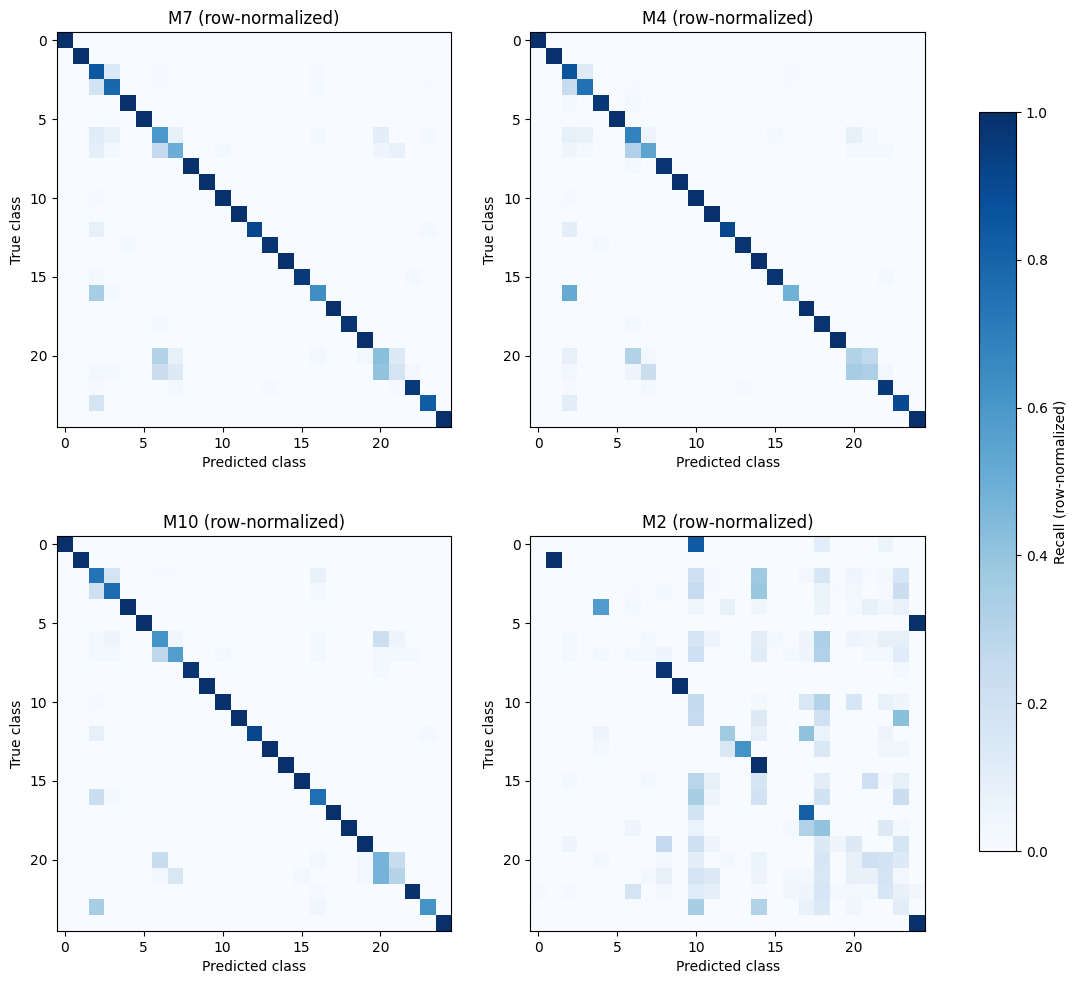

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion(model, name, ax):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{name} (row-normalized)')
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')
    return im

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
models_to_plot = ['M7', 'M4', 'M10', 'M2']

for ax, name in zip(axes.flat, models_to_plot):
    im = plot_confusion(trained_models[name], name, ax)

fig.colorbar(im, ax=axes, shrink=0.8, label='Recall (row-normalized)')
plt.savefig('/kaggle/working/confusion_matrices_32x32.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
import time
import pandas as pd

# Latency: average ms/sample over the test set
latency_results = {}
for name in ['M1','M2','M3','M4','M5','M6','M7','M8','M9','M10','M11','M12']:
    model = trained_models[name]
    # Warm-up call (first call includes graph tracing overhead)
    _ = model.predict(X_test[:32], verbose=0)
    start = time.time()
    _ = model.predict(X_test, verbose=0)
    elapsed = time.time() - start
    latency_results[name] = (elapsed / len(X_test)) * 1000  # ms/sample

# Combine with earlier accuracy/F1 results
final_table = []
for name, params, acc, wf1, mf1 in results:
    final_table.append({
        'Model': name,
        'Params': params,
        'Accuracy': round(acc * 100, 2),
        'Weighted_F1': round(wf1, 3),
        'Macro_F1': round(mf1, 3),
        'Latency_ms': round(latency_results[name], 2)
    })

df = pd.DataFrame(final_table).sort_values('Accuracy', ascending=False)
df.to_csv('/kaggle/working/phase2_32x32_results.csv', index=False)
print(df.to_string(index=False))

Model   Params  Accuracy  Weighted_F1  Macro_F1  Latency_ms
   M7   275065     86.76        0.866     0.864        0.09
   M4  1061497     86.51        0.864     0.872        0.09
   M3  1070745     85.72        0.854     0.856        0.11
   M9   327065     84.19        0.843     0.853        0.10
  M10   327065     83.62        0.841     0.859        0.10
  M11   327065     82.80        0.829     0.858        0.10
   M8    87705     79.51        0.795     0.825        0.10
  M12 26348441     66.88        0.671     0.756        0.33
   M6    17017     65.77        0.674     0.681        0.09
   M1  1061497     61.24        0.602     0.579        0.09
   M5     7769     58.07        0.583     0.478        0.09
   M2  1052249     22.13        0.190     0.271        0.10
